# Современные методы анализа данных и машинного обучения, БИ

## Групповой проект №5. Deep Learning

### EDA для маркетплейса Olist

Идея проекта: сделать систему, которая помогает маркетплейсу заранее видеть риск недовольства клиента и дальше использовать это в поддержке для сокращения оттока клиентов.

У нас в проекте две части:

- табличная модель по заказу и по информации о клиенте оценивает риск плохого опыта пользования нашим маркетплейсом;
- текстовая модель в виде RAG-ассистента будет потом использовать отзывы, контекст клиента и базу знаний, чтобы помочь оператору ответить клиенту.

### В рамках EDA смотрю

- какие таблицы есть и как они связаны;
- какие признаки относятся к клиенту, заказу и отзыву;
- как сейчас выглядят повторные покупки в маркетплейсе;
- по каким признакам можно предсказывать недовольство клиента;
- какие признаки влияют на недовольство клиента;
- как построить датасет для табличной модели и датасет для текстовой модели.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.options.display.float_format = '{:.2f}'.format

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (15, 7)

## Раздел 1. Загрузка данных

Датасет: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [ ]:
customers = pd.read_csv('../data/raws/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/raws/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/raws/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/raws/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/raws/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/raws/olist_orders_dataset.csv')
products = pd.read_csv('../data/raws/olist_products_dataset.csv')
sellers = pd.read_csv('../data/raws/olist_sellers_dataset.csv')
category_translation = pd.read_csv('../data/raws/product_category_name_translation.csv')

## Раздел 2. Первичный осмотр таблиц

Посмотрю на основные таблицы, которые нам интересны: заказы, клиенты, товары, оплата, отзывы и доставка.

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


В payments одна строка — это не всегда один заказ, потому что у заказа может быть несколько платежей. Payment_installments — это количество платежей, то есть что-то похожее на рассрочку.

In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Review_score — это оценка от 1 до 5.

In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


Посмотрим на пропуски и дубликаты.

In [ ]:
summary = pd.DataFrame([
    ['orders', orders.shape[0], orders.shape[1], orders.isna().sum().sum(), orders.duplicated().sum()],
    ['customers', customers.shape[0], customers.shape[1], customers.isna().sum().sum(), customers.duplicated().sum()],
    ['order_items', order_items.shape[0], order_items.shape[1], order_items.isna().sum().sum(), order_items.duplicated().sum()],
    ['payments', payments.shape[0], payments.shape[1], payments.isna().sum().sum(), payments.duplicated().sum()],
    ['reviews', reviews.shape[0], reviews.shape[1], reviews.isna().sum().sum(), reviews.duplicated().sum()],
    ['products', products.shape[0], products.shape[1], products.isna().sum().sum(), products.duplicated().sum()],
    ['sellers', sellers.shape[0], sellers.shape[1], sellers.isna().sum().sum(), sellers.duplicated().sum()],
    ['geolocation', geolocation.shape[0], geolocation.shape[1], geolocation.isna().sum().sum(), geolocation.duplicated().sum()],
    ['category_translation', category_translation.shape[0], category_translation.shape[1], category_translation.isna().sum().sum(), category_translation.duplicated().sum()]
], columns=['table', 'rows', 'cols', 'missing_values', 'duplicates'])

summary.sort_values('rows', ascending=False)

,table,rows,cols,missing_values,duplicates
7,geolocation,1000163,5,0,261831
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
0,orders,99441,8,4908,0
1,customers,99441,5,0,0
4,reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
8,category_translation,71,2,0,0


In [ ]:
print('orders')
print(orders.isna().sum())

print('customers')
print(customers.isna().sum())

print('order_items')
print(order_items.isna().sum())

print('payments')
print(payments.isna().sum())

print('reviews')
print(reviews.isna().sum())

print('products')
print(products.isna().sum())

print('sellers')
print(sellers.isna().sum())

print('geolocation')
print(geolocation.isna().sum())

print('category_translation')
print(category_translation.isna().sum())

orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comm

Пропуски есть в текстовых отзывах, потому что не каждый клиент пишет комментарий. Иногда бывают пропуски в датах доставки, похоже, для тех заказов, которые не дошли до статуса доставленных.

Полные дубли проверили. Теперь проверю дубликаты по основным ID, потому что в будущем придется таблицы совмещать.

In [ ]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [ ]:
customers['customer_id'].duplicated().sum()

np.int64(0)

In [ ]:
customers['customer_unique_id'].duplicated().sum()

np.int64(3345)

In [ ]:
order_items.duplicated(['order_id', 'order_item_id']).sum()

np.int64(0)

In [ ]:
payments.duplicated(['order_id', 'payment_sequential']).sum()

np.int64(0)

In [ ]:
reviews['review_id'].duplicated().sum()

np.int64(814)

In [ ]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [ ]:
products['product_id'].duplicated().sum()

np.int64(0)

In [ ]:
sellers['seller_id'].duplicated().sum()

np.int64(0)

## Раздел 3. Как таблицы связаны между собой

Ключевые ID, которые можно использовать для связей:

- order_id — конкретный заказ;
- customer_id — клиент внутри конкретного заказа;
- customer_unique_id — уникальный клиент;
- product_id — товар;
- seller_id — продавец.

Здесь важно не перепутать customer_id и customer_unique_id. Customer_id относится к заказу, а customer_unique_id больше похож на реального уникального клиента.

In [ ]:
orders['order_id'].nunique(), orders.shape[0]

(99441, 99441)

In [ ]:
customers['customer_id'].nunique(), customers['customer_unique_id'].nunique()

(99441, 96096)

In [ ]:
orders['customer_id'].nunique(), customers['customer_id'].nunique()

(99441, 99441)

Вывод: для таблицы заказов можно соединяться по customer_id, но для анализа retention и повторных покупок нужен customer_unique_id.

Нас интересует информация о клиенте именно по customer_unique_id, потому что это уникальный клиент, а не клиент внутри одного заказа.

## Раздел 4. Даты и динамика заказов

Сейчас даты в таблицах в формате object, переделаю в datetime.

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [ ]:
orders['order_purchase_timestamp'].agg(['min', 'max'])

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [ ]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [ ]:
orders['order_status'].value_counts(normalize=True) * 100

order_status
delivered     97.02
shipped        1.11
canceled       0.63
unavailable    0.61
invoiced       0.32
processing     0.30
created        0.01
approved       0.00
Name: proportion, dtype: float64

In [ ]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_orders = orders.groupby('order_month')['order_id'].nunique()
monthly_orders.head()

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
Name: order_id, dtype: int64

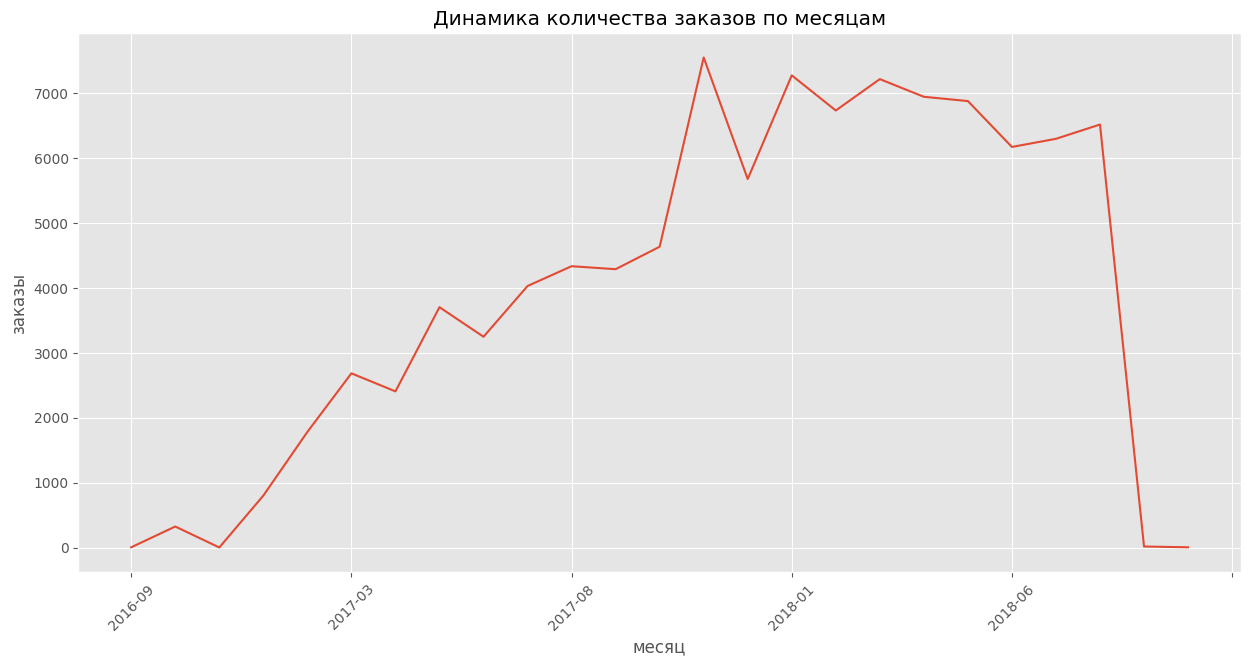

In [ ]:
monthly_orders.plot()
plt.title('Динамика количества заказов по месяцам')
plt.xlabel('месяц')
plt.ylabel('заказы')
plt.xticks(rotation=45)
plt.show()

Вывод: данные идут примерно с сентября 2016 до октября 2018. Основная нормальная часть датасета начинается в 2017 году. В конце 2018 есть обрыв, поэтому с retention-таргетами надо быть осторожным: для последних клиентов мы просто не знаем, вернулись бы они позже или нет.

Весь датасет я здесь не обрезаю, но дальше для проверки возврата за 90 дней будуучитывать.

## Раздел 5. Оплаты и стоимость заказов

Посмотрим, что покупают, сколько это стоит, какие основные метрики по доставке и какие есть способы оплаты.

In [ ]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

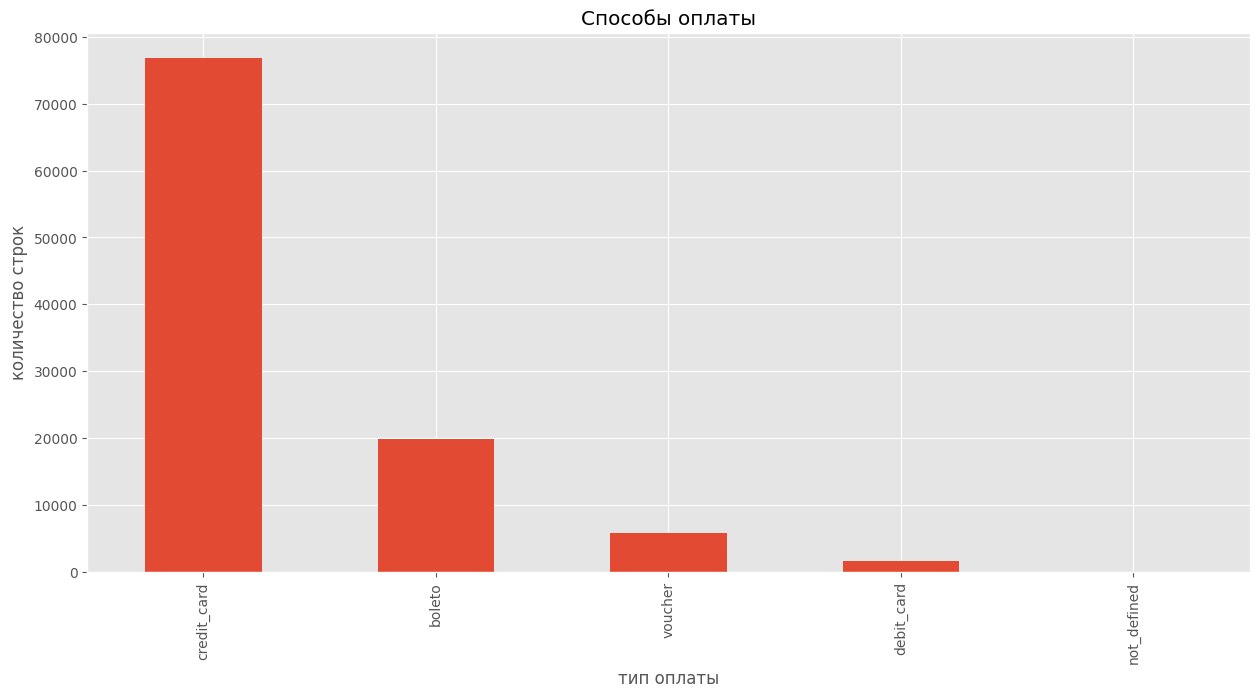

In [ ]:
payments['payment_type'].value_counts().plot(kind='bar')
plt.title('Способы оплаты')
plt.xlabel('тип оплаты')
plt.ylabel('количество строк')
plt.show()

In [ ]:
payment_agg = payments.groupby('order_id').agg({'payment_value': 'sum', 'payment_installments': 'max', 'payment_type': 'nunique'}).reset_index()

payment_agg.columns = ['order_id', 'payment_value', 'payment_installments', 'payment_type_count']
payment_agg.head()

,order_id,payment_value,payment_installments,payment_type_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1


Агрегирую оплаты на уровень заказа: payment_value складываю, payment_installments беру максимальный, а payment_type считаю как количество разных способов оплаты внутри заказа.

In [ ]:
main_payment = payments.groupby('order_id')['payment_type'].agg(lambda x: x.mode().iloc[0]).reset_index()
main_payment.columns = ['order_id', 'main_payment_type']

payment_agg = payment_agg.merge(main_payment, on='order_id', how='left')
payment_agg.head()

,order_id,payment_value,payment_installments,payment_type_count,main_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [ ]:
payment_agg['payment_value'].describe()

count   99440.00
mean      160.99
std       221.95
min         0.00
25%        62.01
50%       105.29
75%       176.97
max     13664.08
Name: payment_value, dtype: float64

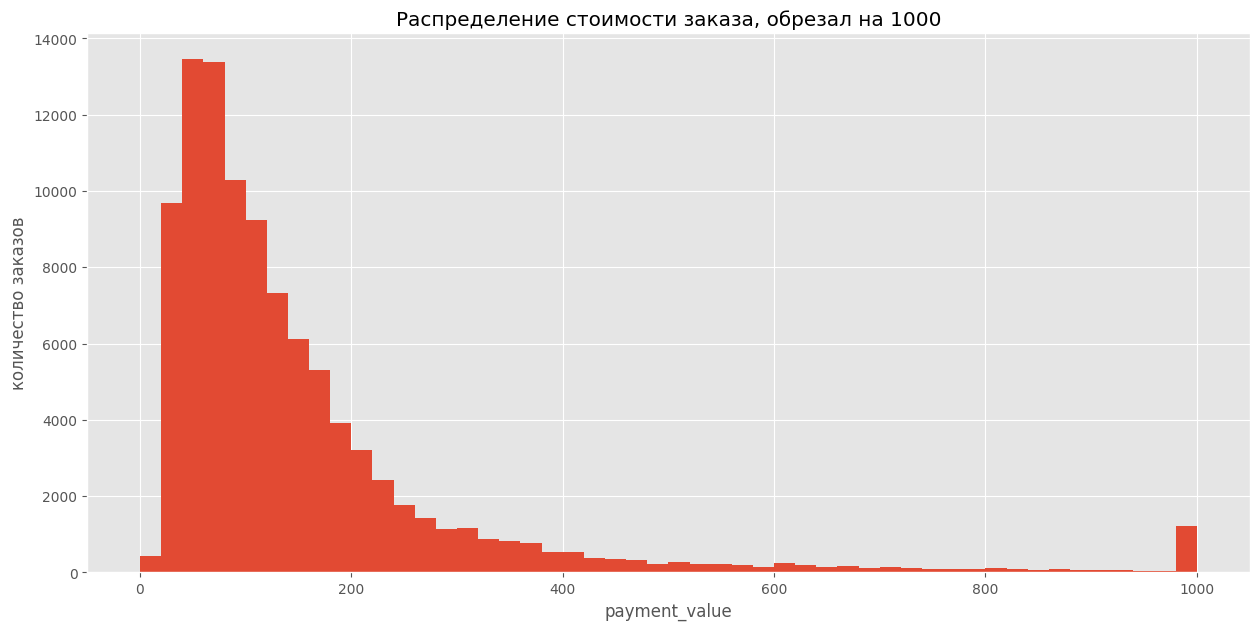

In [ ]:
payment_agg['payment_value'].clip(upper=1000).hist(bins=50)
plt.title('Распределение стоимости заказа, обрезал на 1000')
plt.xlabel('payment_value')
plt.ylabel('количество заказов')
plt.show()

## Раздел 6. Товары и категории

Соберу товары с категориями. Перевод категорий на английский уже есть в отдельной таблице.

In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [ ]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna(products['product_category_name'])
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00,housewares


In [ ]:
items = order_items.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
items['product_category_name_english'] = items['product_category_name_english'].fillna('unknown')
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools


In [ ]:
item_agg = items.groupby('order_id').agg({'order_item_id': 'count', 'product_id': 'nunique', 'seller_id': 'nunique', 'price': 'sum', 'freight_value': 'sum'}).reset_index()

item_agg.columns = ['order_id', 'order_item_count', 'unique_products', 'unique_sellers', 'items_price', 'freight_value']
item_agg.head()

,order_id,order_item_count,unique_products,unique_sellers,items_price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14


In [ ]:
main_category = items.groupby('order_id')['product_category_name_english'].agg(lambda x: x.mode().iloc[0]).reset_index()
main_category.columns = ['order_id', 'main_category']

item_agg = item_agg.merge(main_category, on='order_id', how='left')
item_agg.head()

,order_id,order_item_count,unique_products,unique_sellers,items_price,freight_value,main_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,garden_tools


Теперь у каждого заказа есть количество товаров, количество уникальных товаров, количество продавцов, сумма товаров, стоимость доставки и основная категория.